# Function 2

<b> Description of the Sample Application:</b> Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks


## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 28/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Added Week 2 output.<br>2. Added Week 2 feedback data point.<br>3. Replaced manual grid-search acquisition optimisation with a consolidated, reusable 'bayesian_optimization_step()' function.<br>5. Lowered β further (2.0 → 1.5), continuing the gradual exploration:exploitation shift.|
| 13/08/2026 | Week 4 | 1. Amended Week 3 input and output data points.<br>2. Re-tuned GP kernel: refit with widened length-scale bounds and compared log-marginal-likelihood against the original bounds, since earlier weeks repeatedly hit the upper length-scale bound (convergence warning).<br>3. Compared candidate peak regions found so far (checked whether the good points cluster around one region or suggest multiple local optima).<br>4. Continued lowering β (1.5 → 1.2). |
| 20/08/2026 | **Week 5** | 1. Amended Week 4 input and output data points.<br>2. Ran a plateau check: best-value-found has been flat for 4 consecutive weeks.<br>3. Re-examined the fitted noise level across weeks (found it has grown substantially, weakening confidence that the x1≈0.7 corridor is definitively 'the' peak vs. partly noise).<br>4. Ran an under-sampled-region check and found the low-x1/high-x2 quadrant is by far the least explored area of the domain.<br>5. Checked the naive next global suggestion against Week 4's already-submitted point and found them nearly identical (distance ≈ 0.05) - low marginal information.<br>6. **Strategy change:** based on 3-6, deliberately reversed course - raised β back up (1.2 → 1.8) and restricted this week's search to the identified under-sampled quadrant, instead of continuing to lower β and exploit the same corridor. |
| 02/09/2026 | **Week 6** | 1. Amended Week 5 input and output data points.<br>2. Confirmed the quadrant probe was low-value.<br>3. Found a sampling gap inside the known-good corridor and targeted it, lowering β (1.8 → 1.0). |
| 09/09/2026 | **Week 7** | 1. Amended Week 5 input and output data points.<br>2. Narrowed the confirmed x1 range from 0.6-0.85 down to 0.65–0.75, after noticing x1 = 0.845 performs much worse (y = 0.294) than the x1 ≈ 0.70 points nearby.<br>3. Found the fitted noise level (0.076) is now high enough that the GP's posterior mean is nearly flat across the untested x2 gap (0.65-0.93). The model can't distinguish a real peak from noise in this region anymore.<br>4. **Manually overrode the acquisition suggestion** (which nearly repeated a known point due to this flat posterior) and queried the midpoint of the gap directly, for genuine information gain.<br>5. Lowered β further (1.0 → 0.7), reflecting continued movement toward exploitation. |

# Weekly Progress Log

| Week | Query Submitted (x1-x2) | Output (y) | Acquisition | β (beta) | Kernel | Notes |
|---|---|---|---|---|---|---|
| Week 1 | 0.725451-0.000000 | 0.594526 | UCB | 2.5 | RBF | First submission-exploration-heavy (edge of domain, x2 = 0) |
| Week 2 | 0.959920-0.959920 | -0.053255 | UCB | 2.0 | RBF | Exploring the opposite corner (x1 ≈ x2 ≈ 0.96); output far lower than the GP's predicted mean (μ ≈ 0.39), which is a strong signal the RBF surrogate overestimated that corn| 
| Week 3 | 0.698058-0.000000 | 0.466845 | UCB | 1.5 | RBF (multi-start L-BFGS-B) | Query landed close to Week 1's point; confirmed the x2 ≈ 0 corridor around x1 ≈ 0.70–0.73 is a genuinely strong region |
| Week 4 | 0.741335-1.000000 | 0.436016 | UCB | 1.2 | RBF (widened bounds) | Query landed near the rank-1 best but scored notably lower (0.436 vs. 0.611) - the x1≈0.7 corridor is good but not uniformly peaked; best-so-far still unchanged after 4 weeks |
| Week 5 | 0.050000-0.950000 | -0.044685 | UCB | 1.8 (raised) | RBF | Deliberate quadrant probe (low x1, high x2); result confirms this region is low-value, similar to Week 2's corner miss |
| Week 6 | 0.697679-0.650000 | **0.619497** | UCB | 1.0 | RBF | Targeting the untested x2 gap (≈0.13–0.65) within the confirmed x1≈0.6–0.85 corridor, instead of a new region or a repeat query |
| Week 7 | - | - | UCB (**manually overridden**) | 0.7 (lowered further) | RBF | Targeting the midpoint of the remaining gap between the two best points (x2≈0.65 and x2≈0.93), after the model's high noise estimate made the automatic suggestion unreliable |

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import plot_2d_bo_state, plot_convergence
from scipy.optimize import minimize

# Load and Analyse the Data

In [11]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
Y       = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.725451, 0.     ]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([0.5945255267146322]  , dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.95992, 0.95992]     , dtype=np.float64)   # from input.txt
Y_w2_new_point = np.array([-0.053254980810696906], dtype=np.float64)   # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.698058, 0.      ]   , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([0.46684490847445986]  , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.741335, 1.0]        , dtype=np.float64)    # from input.txt
Y_w4_new_point = np.array([0.4360156328364332]   , dtype=np.float64)    # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.05, 0.95]            , dtype=np.float64)    # from input.txt
Y_w5_new_point = np.array([-0.044684125031317246] , dtype=np.float64)    # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.697679, 0.65]        , dtype=np.float64)    # from input.txt
Y_w6_new_point = np.array([0.6194965226381177]    , dtype=np.float64)    # from output.txt

In [13]:
# Append the new data points
X_updated      = np.vstack((X, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                             , X_w4_new_point
                             , X_w5_new_point
                             , X_w6_new_point
                           ))
Y_updated      = np.append(Y, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                            , Y_w4_new_point
                            , Y_w5_new_point
                            , Y_w6_new_point
                              ])

In [15]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]
 [0.95992    0.95992   ]
 [0.698058   0.        ]
 [0.741335   1.        ]
 [0.05       0.95      ]
 [0.697679   0.65      ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553 -0.05325498
  0.46684491  0.43601563 -0.04468413  0.61949652]


In [17]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()
print("Minimum and Maximum Values of Output:\n")
print("Min:", Y.min(), " Max:", Y.max())
print("Best point:", X[np.argmax(Y)], "-> Output =", Y.max())
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (16, 2)
Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]
 [0.95992    0.95992   ]
 [0.698058   0.        ]
 [0.741335   1.        ]
 [0.05       0.95      ]
 [0.697679   0.65      ]]

Output Shape: (16,)
Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553 -0.05325498
  0.46684491  0.43601563 -0.04468413  0.61949652]

Minimum and Maximum Values of Output:

Min: -0.06562362443733738  Max: 0.6194965226381177
Best point: [0.697679 0.65    ] -> Output = 0.6194965226381177

Data Frame:
          X_1       X_2         Y
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.45

# Data Exploration

In [20]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2          Y
count  16.000000  16.000000  16.000000
mean    0.578598   0.527451   0.270355
std     0.261242   0.374071   0.260851
min     0.050000   0.000000  -0.065624
25%     0.414062   0.191393   0.013865
50%     0.681739   0.667509   0.269306
75%     0.729422   0.815612   0.484883
max     0.959920   1.000000   0.619497


In [22]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
Y      0
dtype: int64


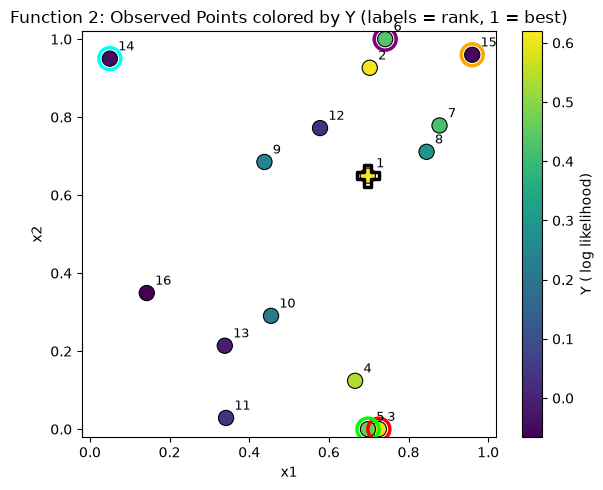

In [26]:
# Scatter Plot
fig, ax   = plt.subplots(figsize = (6,5))
sc        = ax.scatter(X[:,0], X[:,1], c = Y, cmap = 'viridis', s = 120, edgecolor = 'black', linewidth = 0.8)

# Highlighting Week 1 submitted point with a distinct marker
ax.scatter(X_w1_new_point[0], X_w1_new_point[1], facecolor = 'none', edgecolor = 'red', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 1 query')

# --- Week 2 Points ---
ax.scatter(X_w2_new_point[0], X_w2_new_point[1], facecolor = 'none', edgecolor = 'orange', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 2 query')

# --- Week 3 ---
ax.scatter(X_w3_new_point[0], X_w3_new_point[1], facecolor = 'none', edgecolor = 'lime', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 3 query')

# --- Week 4 ---
ax.scatter(X_w4_new_point[0], X_w4_new_point[1], facecolor = 'none', edgecolor = 'purple', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 4 query')

# --- Week 5 ---
ax.scatter(X_w5_new_point[0], X_w5_new_point[1], facecolor = 'none', edgecolor = 'cyan', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 5 query')

# --- Week 6 ---
ax.scatter(X_w6_new_point[0], X_w6_new_point[1], facecolor = 'none', edgecolor = 'black', linewidth = 2.5, s = 250, marker = 'P', label = 'Week 6 query (new best)')

ranks = (-Y).argsort().argsort() + 1
for i, (px, py) in enumerate(X):
    ax.annotate(str(ranks[i]), (px, py), textcoords = "offset points", xytext=(6, 6), fontsize = 9)
    
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title('Function 2: Observed Points colored by Y (labels = rank, 1 = best)')
fig.colorbar(sc, ax = ax, label = "Y ( log likelihood)")
plt.tight_layout()
plt.show()

**Note:** the **Week 1** query landed at x2 = 0.000000 (domain boundary), consistent with the high exploration weight (β = 2.5) used that week. Its output (y = 0.594526) is close to the current best (y = 0.611205 at rank 1), reinforcing that the region around x1 ≈ 0.7–0.9, low-to-mid x2 is promising and worth continued attention alongside the still-unexplored gaps.<br> The **Week 2** query at the opposite corner (x1 ≈ x2 ≈ 0.96) told a very different story: the GP's posterior mean there was optimistic (μ ≈ 0.39), but the true output came back at y = -0.053255, well below prediction. This is a useful information. The RBF kernel's smooth extrapolation into a far corner with no nearby observations was overconfident, and this corner should now be treated as low-value rather than promising.<br>
The **Week 3** query (x1 = 0.698058, x2 = 0.000000) landed almost on top of Week 1's point and returned y = 0.466845: a solid result, and further confirmation that the corridor around x1 ≈ 0.70–0.73, x2 ≈ 0 is a genuine, repeatable strong region. Combined with the rank-1 best sitting nearby at x1 ≈ 0.70, x2 ≈ 0.93, this raises a reasonable question worth checking in Week 4: is this one broad ridge along x1 ≈ 0.7, or are the low-x2 and high-x2 ends actually two separate peaks connected by a lower-value middle?
The **Week 4** query (x1=0.741335, x2=1.000000) landed right next to the rank-1 best point but scored **y = 0.436016**, which is noticeably lower than the rank-1 best (0.611) just 0.07 away in x2. Combined with Week 1/3's results at x2=0 (0.5–0.6), the x1≈0.7 corridor does **not** look like a flat plateau after all: output varies meaningfully across x2 even within this narrow x1 band. After 4 weeks, the best value found has not improved beyond the original data at all - this plateau, together with a reassessment of the noise level, motivated a deliberate strategy change this week.
**Week 7** The **Week 6** query (x1=0.697679, x2=0.65) returned **y = 0.619497**, the first query in this whole project to beat the original data's best point (0.611205). This strongly confirms x1≈0.70 is the right column, and narrows attention to the x2 range between 0.65 and 0.93, where both endpoints now score above 0.61. However, note that a nearby point at x1=0.845 (still within the old, wider corridor definition) scored only 0.294. So the genuinely strong region is narrower in x1 than previously assumed.

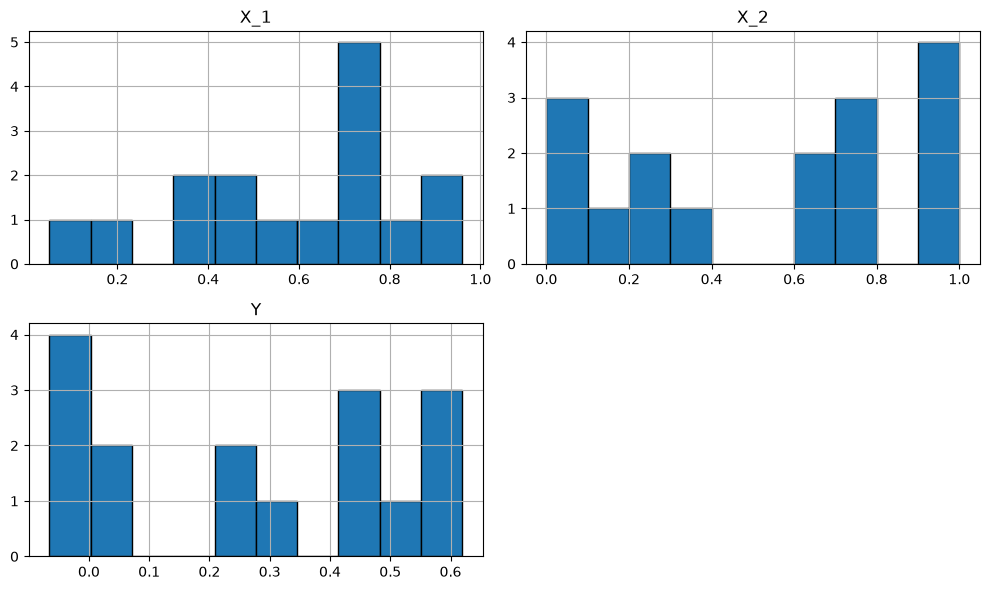

In [42]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'black' )
plt.tight_layout()
plt.show()

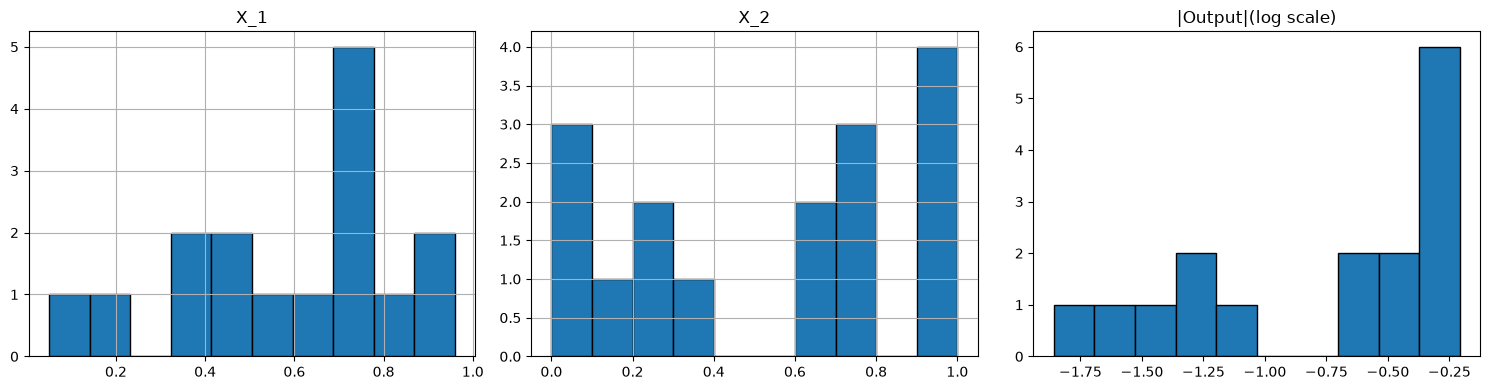

In [44]:
# In the above histogram for the output column, almost every bar seems to be crammed into a single bin near zero, which is not very informative.
# Plotting the column histograms using log scale for Output column
fig, axes = plt.subplots(1,3, figsize = (15,4))

df['X_1'].hist(ax = axes[0], bins = 10, edgecolor = 'black')
axes[0].set_title('X_1')

df['X_2'].hist(ax = axes[1], bins = 10, edgecolor = 'black')
axes[1].set_title('X_2')

magnitude = np.where(Y != 0, np.log10(np.abs(Y) + 1e-300), np.nan)
axes[2].hist(magnitude, bins = 10, edgecolor = 'black')
axes[2].set_title('|Output|(log scale)')


plt.tight_layout()
plt.show()

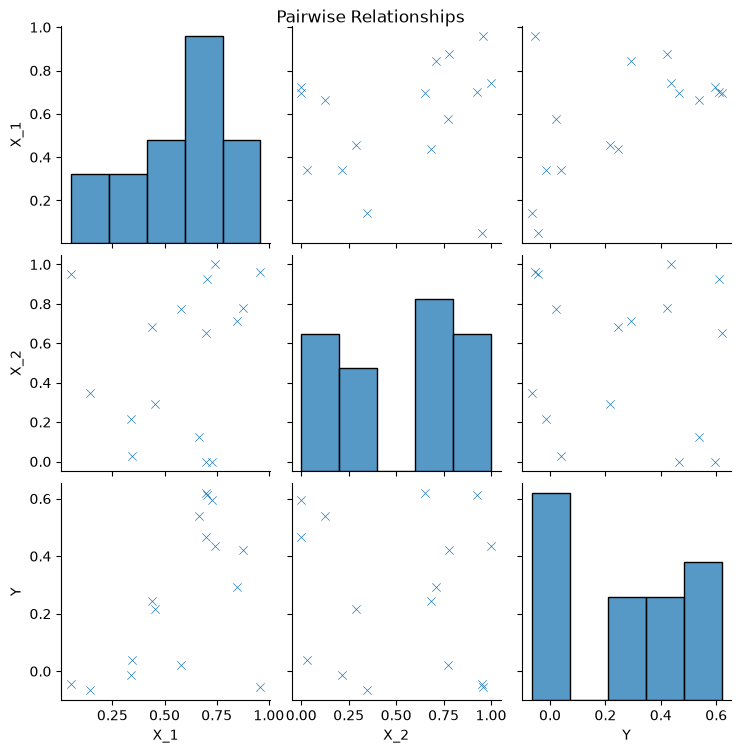

In [46]:
# Understanding the relationships between the variables using a Pair Plot
sns.pairplot(df, kind = 'scatter', diag_kind = 'hist', markers = 'x')
plt.suptitle('Pairwise Relationships', verticalalignment = 'baseline')
plt.show()

# Initialize Gaussian Process

In [49]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [52]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.939**2 * RBF(length_scale=[0.0338, 0.98]) + WhiteKernel(noise_level=1e-05)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- **Week 1:** uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.
- **Week 2:** β is lowered to **2.0**, to shift from exploration toward exploitation.

In [60]:
grid_res   = 500
xs         = np.linspace(0, 1, grid_res)
ys         = np.linspace(0, 1, grid_res)
gx, gy     = np.meshgrid(xs, ys)
candidates = np.column_stack([gx.ravel(), gy.ravel()])

mu, std    = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
#beta       = 2.5    #Week 1 
beta       = 2.0    #Week 2 
ucb        = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.66132265 1.        ]
Predicted Mean(μ): 6.023017e-01
Predicted Std (σ): 1.460737e-01
UCB Score: 8.944490e-01


# Perform Visualisation ( Week 1 )

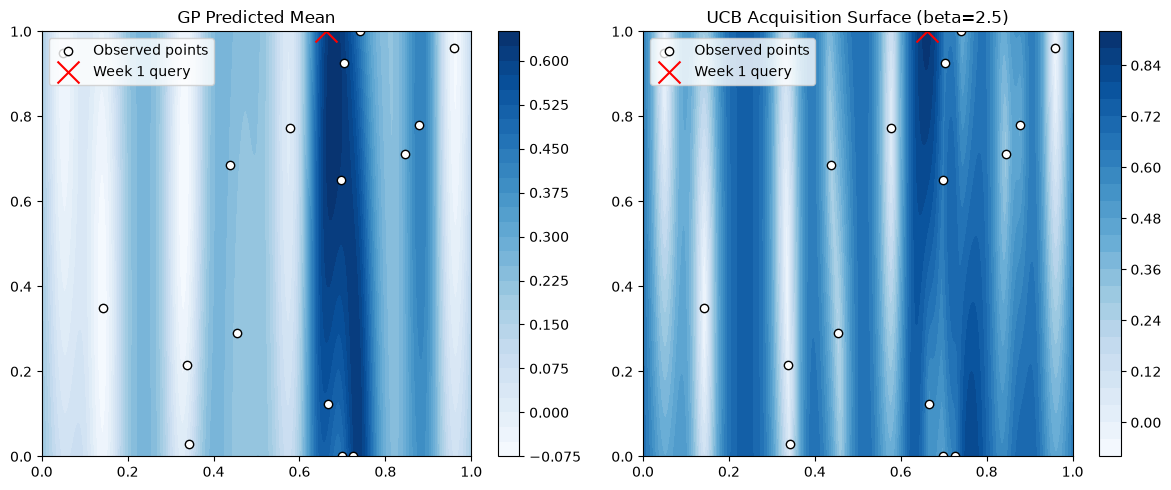

In [63]:
fig, axes  = plt.subplots(1,2, figsize = (12, 5))

# Predicted mean surface
c0 = axes[0].contourf(gx, gy, mu.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[0].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[0].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[0].set_title("GP Predicted Mean")
axes[0].legend(loc = 'upper left')
fig.colorbar(c0, ax=axes[0])

# UCB acquisition surface
c1 = axes[1].contourf(gx, gy, ucb.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[1].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[1].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[1].set_title("UCB Acquisition Surface (beta=2.5)")
axes[1].legend(loc = 'upper left')
fig.colorbar(c1, ax = axes[1])

plt.tight_layout()
plt.show()

# Week 2 Visualisation

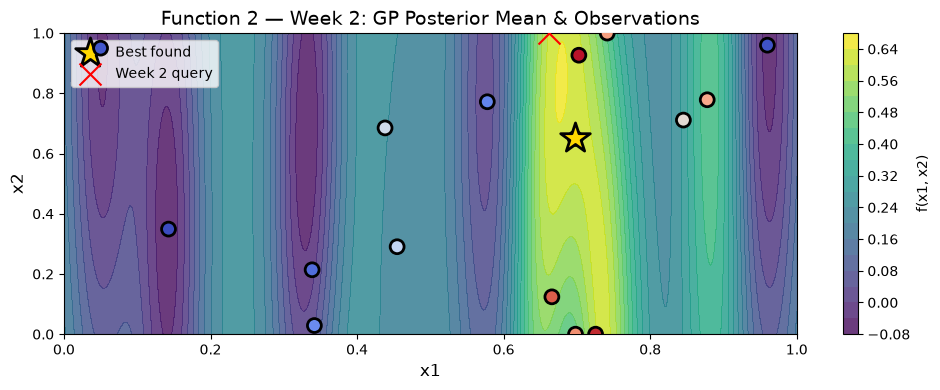

In [66]:
Z_mu = mu.reshape(gx.shape)

fig, ax = plot_2d_bo_state(gx, gy, Z_mu, X, Y, title='Function 2 \u2014 Week 2: GP Posterior Mean & Observations')
ax.scatter(*next_point, c = 'red', marker = 'x', s = 250, label = 'Week 2 query', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Week 3: Consolidated Bayesian Optimization Function

In [69]:
# Week 3: Consolidated Bayesian Optimization Function
def bayesian_optimization_step(X, y, bounds, beta = 2.0, kernel = None,
                                n_restarts = 20, random_state = 42):
    if kernel is None:
        kernel = (ConstantKernel(1.0, (1e-1, 1e2))
                  * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 2.0))
                  + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0)))

    gp         = GaussianProcessRegressor(kernel=kernel, normalize_y = True,
                                  n_restarts_optimizer = 10, random_state = random_state)
    gp.fit(X, y)

    def neg_ucb(x):
        x         = np.array(x).reshape(1, -1)
        mu, sigma = gp.predict(x, return_std = True)
        return -(mu[0] + beta * sigma[0])

    lows          = [b[0] for b in bounds]
    highs         = [b[1] for b in bounds]

    best_val      = np.inf
    best_x        = None
    rng           = np.random.default_rng(random_state)
    for _ in range(n_restarts):
        x0        = rng.uniform(lows, highs)
        result    = minimize(neg_ucb, x0, bounds = bounds, method = 'L-BFGS-B')
        if result.fun < best_val:
            best_val = result.fun
            best_x   = result.x

    mu_next, std_next = gp.predict(best_x.reshape(1, -1), return_std = True)

    return {
        'gp': gp,
        'next_point': best_x,
        'mu': mu_next[0],
        'std': std_next[0],
        'ucb': -best_val,
    }

In [71]:
# Run the consolidated function for Week 3
# lowered value of beta from Week 2's 2.0 to 1.5
beta             = 1.5   
bounds_2d        = [(0.0, 1.0), (0.0, 1.0)]

result_week3     = bayesian_optimization_step(X, Y, bounds_2d, beta = beta)

next_point_week3 = result_week3['next_point']

print(f"Suggested Week 3 Query Point: {next_point_week3}")
print(f"Predicted Mean(\u03bc): {result_week3['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week3['std']:.6e}")
print(f"UCB Score: {result_week3['ucb']:.6e}")


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 3 Query Point: [0.66407876 1.        ]
Predicted Mean(μ): 6.125074e-01
Predicted Std (σ): 1.400051e-01
UCB Score: 8.225150e-01


# Week 3 Visualisation

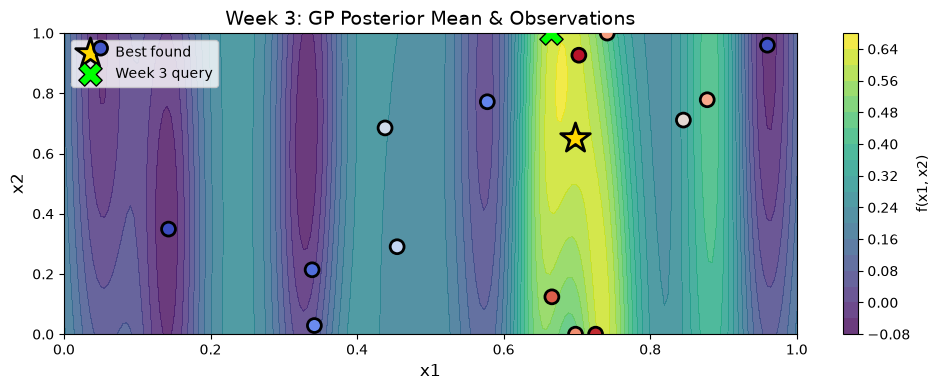

In [74]:
grid_res_w3   = 200
xs_w3         = np.linspace(0, 1, grid_res_w3)
ys_w3 = np.linspace(0, 1, grid_res_w3)
gx_w3, gy_w3  = np.meshgrid(xs_w3, ys_w3)
grid_w3       = np.column_stack([gx_w3.ravel(), gy_w3.ravel()])

mu_grid_w3, _ = result_week3['gp'].predict(grid_w3, return_std = True)
Z_mu_w3       = mu_grid_w3.reshape(gx_w3.shape)

fig, ax       = plot_2d_bo_state(gx_w3, gy_w3, Z_mu_w3, X, Y,
                            title = 'Week 3: GP Posterior Mean & Observations')
ax.scatter(*next_point_week3, c = 'lime', marker = 'X', s = 280,
           edgecolor = 'black', label = 'Week 3 query', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Week 4: Compare Candidate Peak Regions Found So Far

Before querying again, it's worth checking whether the top-performing points found so far cluster into one region or several. This directly informs whether Week 4 should exploit one area or continue probing for a second optimum.

In [77]:
top_k        = 4
top_idx      = np.argsort(-Y)[:top_k]

print(f"Top {top_k} points by output value:\n")
for rank, i in enumerate(top_idx, start=1):
    print(f"  Rank {rank}: x = ({X[i,0]:.4f}, {X[i,1]:.4f}), y = {Y[i]:.4f}")

# Pairwise distance between the top points, to check if they're clustered
# (one region) or spread apart (possible separate local optima)
from scipy.spatial.distance import pdist, squareform
top_X       = X[top_idx]
dist_matrix = squareform(pdist(top_X))
print("\nPairwise distances among top points:\n", np.round(dist_matrix, 3))

max_dist    = dist_matrix.max()
print(f"\nMax distance among top {top_k} points: {max_dist:.3f}")
if max_dist > 0.5:
    print("Top points are spread apart => consistent with more than one promising region.")
else:
    print("Top points are relatively close together => consistent with a single broad region.")

Top 4 points by output value:

  Rank 1: x = (0.6977, 0.6500), y = 0.6195
  Rank 2: x = (0.7026, 0.9266), y = 0.6112
  Rank 3: x = (0.7255, 0.0000), y = 0.5945
  Rank 4: x = (0.6658, 0.1240), y = 0.5390

Pairwise distances among top points:
 [[0.    0.277 0.651 0.527]
 [0.277 0.    0.927 0.803]
 [0.651 0.927 0.    0.138]
 [0.527 0.803 0.138 0.   ]]

Max distance among top 4 points: 0.927
Top points are spread apart => consistent with more than one promising region.


# Week 4: Kernel Re-tuning Check
Across Weeks 1–3, the fitted RBF kernel's x2 length-scale has repeatedly settled at or near its upper bound (2.0), triggering a scikit-learn convergence warning each time. This can mean the model wants an even larger length-scale than allowed (i.e., it thinks the function is smoother/flatter along x2 than the bound permits). Worth checking directly rather than ignoring the warning again this week.

In [80]:
# Original kernel (bounds used since Week 1): length_scale_bounds = (1e-2, 2.0)
log_ml_original  = gpr.log_marginal_likelihood(gpr.kernel_.theta)
print(f"Original kernel:              {gpr.kernel_}")
print(f"Log-marginal-likelihood:      {log_ml_original:.4f}")

# Widened-bounds candidate: let the length-scale optimiser search further,
# in case the true optimum lies beyond the original 2.0 cap
kernel_rbf_wide  = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 5.0)) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_wide = GaussianProcessRegressor(kernel = kernel_rbf_wide, normalize_y = True,
                                     n_restarts_optimizer = 10, random_state = 42)
gpr_wide.fit(X, Y)
log_ml_wide      = gpr_wide.log_marginal_likelihood(gpr_wide.kernel_.theta)
print(f"\nWidened-bounds kernel:        {gpr_wide.kernel_}")
print(f"Log-marginal-likelihood:      {log_ml_wide:.4f}")

# Adopt whichever kernel fits better (higher log-marginal-likelihood)
if log_ml_wide > log_ml_original:
    print("\n-> Widened-bounds kernel fits better; using it for Week 4's acquisition step.")
    kernel_week4 = gpr_wide.kernel_
else:
    print("\n-> Original kernel bounds were already adequate; keeping them for Week 4.")
    kernel_week4 = gpr.kernel_

Original kernel:              0.939**2 * RBF(length_scale=[0.0338, 0.98]) + WhiteKernel(noise_level=1e-05)
Log-marginal-likelihood:      -16.0578

Widened-bounds kernel:        0.92**2 * RBF(length_scale=[0.0562, 5]) + WhiteKernel(noise_level=0.0757)
Log-marginal-likelihood:      -15.8915

-> Widened-bounds kernel fits better; using it for Week 4's acquisition step.


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Week 4: Running the Consolidated Function with the Re-tuned Kernel

In [83]:
beta_week4       = 1.2   # lowered from Week 3's 1.5
bounds_2d        = [(0.0, 1.0), (0.0, 1.0)]

result_week4     = bayesian_optimization_step(X, Y, bounds_2d, beta = beta_week4, kernel = kernel_week4)

next_point_week4 = result_week4['next_point']

print(f"Suggested Week 4 Query Point: {next_point_week4}")
print(f"Predicted Mean(\u03bc): {result_week4['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week4['std']:.6e}")
print(f"UCB Score: {result_week4['ucb']:.6e}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 4 Query Point: [0.69583091 1.        ]
Predicted Mean(μ): 5.795053e-01
Predicted Std (σ): 8.141174e-02
UCB Score: 6.771994e-01


# Week 4: Visualisation

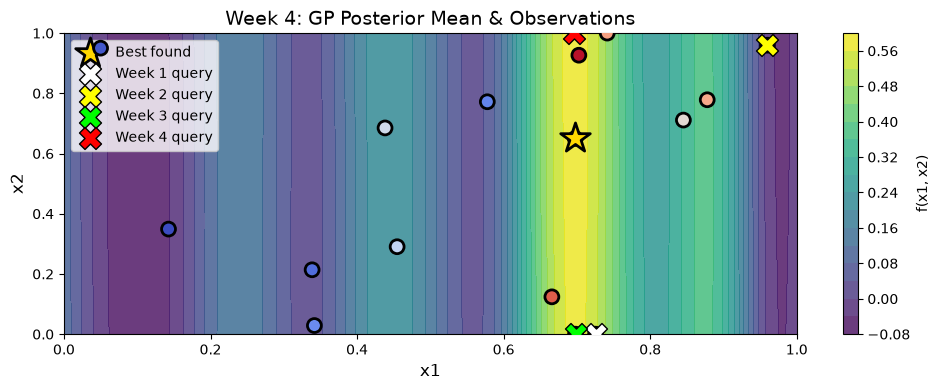

In [86]:
grid_res_w4   = 200
xs_w4         = np.linspace(0, 1, grid_res_w4)
ys_w4         = np.linspace(0, 1, grid_res_w4)
gx_w4, gy_w4  = np.meshgrid(xs_w4, ys_w4)
grid_w4       = np.column_stack([gx_w4.ravel(), gy_w4.ravel()])

mu_grid_w4, _ = result_week4['gp'].predict(grid_w4, return_std=True)
Z_mu_w4       = mu_grid_w4.reshape(gx_w4.shape)

fig, ax       = plot_2d_bo_state(gx_w4, gy_w4, Z_mu_w4, X, Y,
                            title='Week 4: GP Posterior Mean & Observations')
ax.scatter(*X_w1_new_point, c = 'white' , marker = 'X', s = 250, edgecolor ='black', label='Week 1 query', zorder = 12)
ax.scatter(*X_w2_new_point, c = 'yellow', marker = 'X', s = 250, edgecolor ='black', label='Week 2 query', zorder = 12)
ax.scatter(*X_w3_new_point, c = 'lime'  , marker = 'X', s = 250, edgecolor ='black', label='Week 3 query', zorder = 12)

ax.scatter(*next_point_week4, c = 'red' , marker = 'X', s = 250, edgecolor ='black', label='Week 4 query', zorder = 12)

ax.legend(loc = 'upper left')
plt.show()

# Week 5: Comparing noise level with incremental data

In [89]:
snapshots = [
    ('After initial 10 pts',  X_updated[:10],  Y_updated[:10]),
    ('After Week 1 (11 pts)', X_updated[:11],  Y_updated[:11]),
    ('After Week 3 (13 pts)', X_updated[:13],  Y_updated[:13]),
    ('After Week 4 (14 pts)', X_updated[:14],  Y_updated[:14]),
]
for label, Xs, Ys in snapshots:
    k = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale=[0.25, 0.25], length_scale_bounds=(1e-2, 2.0)) \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e0))
    g = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=10, random_state=42)
    g.fit(Xs, Ys)
    noise = g.kernel_.k2.noise_level
    print(f"{label}: fitted noise_level = {noise:.4f}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After initial 10 pts: fitted noise_level = 0.0148


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After Week 1 (11 pts): fitted noise_level = 0.0125


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After Week 3 (13 pts): fitted noise_level = 0.0364
After Week 4 (14 pts): fitted noise_level = 0.0932


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


**Note:** Noise estimates have grown substantially as more data arrived.

# Week 5: Checking for under-sampled regions

In [93]:
grid_res_gap = 200
xs_gap = np.linspace(0, 1, grid_res_gap)
ys_gap = np.linspace(0, 1, grid_res_gap)
gx_gap, gy_gap = np.meshgrid(xs_gap, ys_gap)
grid_gap = np.column_stack([gx_gap.ravel(), gy_gap.ravel()])

from scipy.spatial.distance import cdist
dists_gap = cdist(grid_gap, X_updated)
min_dist_gap = dists_gap.min(axis=1)

quadrants = {
    'low x1, low x2':   (grid_gap[:, 0] < 0.5) & (grid_gap[:, 1] < 0.5),
    'low x1, high x2':  (grid_gap[:, 0] < 0.5) & (grid_gap[:, 1] >= 0.5),
    'high x1, low x2':  (grid_gap[:, 0] >= 0.5) & (grid_gap[:, 1] < 0.5),
    'high x1, high x2': (grid_gap[:, 0] >= 0.5) & (grid_gap[:, 1] >= 0.5),
}
print("Average distance to nearest observed point, by quadrant:\n")
for name, mask in quadrants.items():
    print(f"  {name:20s}: {min_dist_gap[mask].mean():.4f}")


Average distance to nearest observed point, by quadrant:

  low x1, low x2      : 0.1227
  low x1, high x2     : 0.1712
  high x1, low x2     : 0.1836
  high x1, high x2    : 0.0926


**Observation:** Low x1, High x2 is a clear gap. Almost entirely unsampled so far.
**Decision   :** Above checks all point the same direction - a rising noise estimate that weakens confidence in the corridor's apparent edge, and a large, genuinely under-sampled region (low x1, high x2) that hasn't been tested at all. This is a reasonable basis to **change strategy in week 5**. Rather than continuing to lower β and refine around the same corridor, β is raised back up (1.2 to 1.8) and this week's search is deliberately pointed at the under-sampled quadrant, to check whether a second, better optimum exists there before committing to further local refinement.

One more check before committing to this: does the *default* global acquisition search even still want to revisit the same corridor, or has it already started drifting toward new ground on its own?

In [96]:
probe_result = bayesian_optimization_step(X_updated, Y_updated, [(0.0, 1.0), (0.0, 1.0)],
                                           beta=1.8, kernel=kernel_week4)
probe_point = probe_result['next_point']
dist_to_week4 = np.linalg.norm(probe_point - X_w4_new_point)

print(f"Naive global suggestion (beta=1.8): {probe_point}")
print(f"Distance to Week 4's already-submitted point: {dist_to_week4:.4f}")
if dist_to_week4 < 0.1:
    print("Nearly a repeat of Week 4's query(low marginal information). Overriding with a deliberately restricted search of the under-sampled quadrant instead.")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Naive global suggestion (beta=1.8): [0.69491192 1.        ]
Distance to Week 4's already-submitted point: 0.0464
Nearly a repeat of Week 4's query(low marginal information). Overriding with a deliberately restricted search of the under-sampled quadrant instead.


# Week 5: Querying the under-sampled quadrant

In [99]:
beta_week5 = 1.8   # raised from Week 4's 1.2 -- deliberate strategy reversal
bounds_quadrant = [(0.05, 0.45), (0.55, 0.95)]   # under-sampled region, inset from domain edges

result_week5 = bayesian_optimization_step(X_updated, Y_updated, bounds_quadrant,
                                           beta=beta_week5, kernel=kernel_week4)

next_point_week5 = result_week5['next_point']

print(f"Suggested Week 5 Query Point: {next_point_week5}")
print(f"Predicted Mean(\u03bc): {result_week5['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week5['std']:.6e}")
print(f"UCB Score: {result_week5['ucb']:.6e}")
print()

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 5 Query Point: [0.24025807 0.95      ]
Predicted Mean(μ): 1.549159e-01
Predicted Std (σ): 2.323979e-01
UCB Score: 5.732321e-01



# Week 5: Visualisation

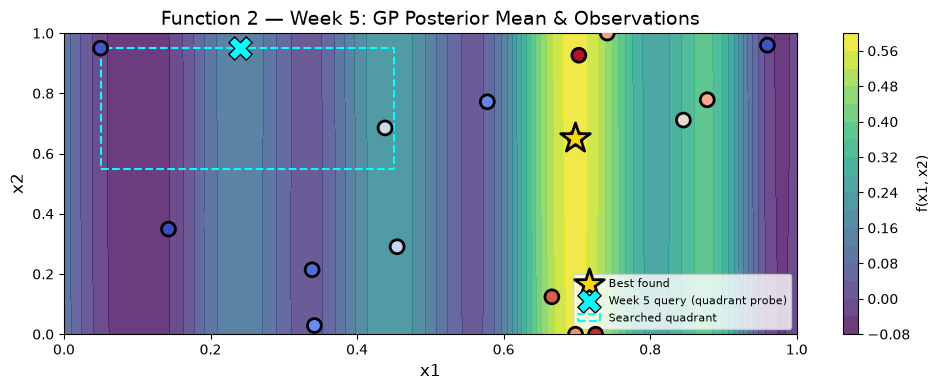

In [102]:
grid_res_w5 = 200
xs_w5 = np.linspace(0, 1, grid_res_w5)
ys_w5 = np.linspace(0, 1, grid_res_w5)
gx_w5, gy_w5 = np.meshgrid(xs_w5, ys_w5)
grid_w5 = np.column_stack([gx_w5.ravel(), gy_w5.ravel()])

mu_grid_w5, _ = result_week5['gp'].predict(grid_w5, return_std=True)
Z_mu_w5 = mu_grid_w5.reshape(gx_w5.shape)

fig, ax = plot_2d_bo_state(gx_w5, gy_w5, Z_mu_w5, X_updated, Y_updated,
                            title='Function 2 \u2014 Week 5: GP Posterior Mean & Observations')
ax.scatter(*next_point_week5, c='cyan', marker='X', s=280,
           edgecolor='black', label='Week 5 query (quadrant probe)', zorder=12)

import matplotlib.patches as patches
rect = patches.Rectangle((0.05, 0.55), 0.40, 0.40, linewidth=1.5, edgecolor='cyan',
                          facecolor='none', linestyle='--', label='Searched quadrant')
ax.add_patch(rect)
ax.legend(loc='lower right', fontsize=8)
plt.show()

# Week 6: Check for a Sampling Gap Inside the Known-Good Corridor

Week 5 ruled out the low-x1/high-x2 quadrant. Before deciding where to query next, it's worth checking the confirmed strong region (x1 ≈ 0.6–0.85) more closely - specifically, which x2 values have and haven't been tested there yet.

In [105]:
corridor_mask = (X_updated[:, 0] > 0.6) & (X_updated[:, 0] < 0.85)
corridor_pts  = X_updated[corridor_mask]
corridor_y    = Y_updated[corridor_mask]
order         = np.argsort(corridor_pts[:, 1])

print("Points with x1 in [0.6, 0.85], sorted by x2:\n")
for xi, yi in zip(corridor_pts[order], corridor_y[order]):
    print(f"  x = ({xi[0]:.4f}, {xi[1]:.4f})   y = {yi:.4f}")

x2_values = np.sort(corridor_pts[:, 1])
gaps      = np.diff(x2_values)
largest_gap_idx = np.argmax(gaps)
print(f"\nLargest untested x2 gap in this corridor: {x2_values[largest_gap_idx]:.3f} "
      f"to {x2_values[largest_gap_idx+1]:.3f} (width = {gaps[largest_gap_idx]:.3f})")

Points with x1 in [0.6, 0.85], sorted by x2:

  x = (0.7255, 0.0000)   y = 0.5945
  x = (0.6981, 0.0000)   y = 0.4668
  x = (0.6658, 0.1240)   y = 0.5390
  x = (0.6977, 0.6500)   y = 0.6195
  x = (0.8453, 0.7111)   y = 0.2940
  x = (0.7026, 0.9266)   y = 0.6112
  x = (0.7413, 1.0000)   y = 0.4360

Largest untested x2 gap in this corridor: 0.124 to 0.650 (width = 0.526)


 **Observation:** This gap is the target for Week 6's query. Exploit the known-good x1 range while filling in the one part of it that hasn't been observed yet.

# Week 6: Run the Consolidated Function, Targeting the Corridor Gap

In [109]:
beta_week6 = 1.0   # lowered from Week 5's 1.8 -- back to exploitation, but of new ground
bounds_gap = [(0.6, 0.85), (0.2, 0.65)]   # confirmed-good x1 range x untested x2 gap

result_week6 = bayesian_optimization_step(X_updated, Y_updated, bounds_gap,
                                           beta=beta_week6, kernel=kernel_week4)

next_point_week6 = result_week6['next_point']

print(f"Suggested Week 6 Query Point: {next_point_week6}")
print(f"Predicted Mean(\u03bc): {result_week6['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week6['std']:.6e}")
print(f"UCB Score: {result_week6['ucb']:.6e}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 6 Query Point: [0.69679823 0.65      ]
Predicted Mean(μ): 5.780008e-01
Predicted Std (σ): 7.843024e-02
UCB Score: 6.564311e-01


# Week 6 Visualisation

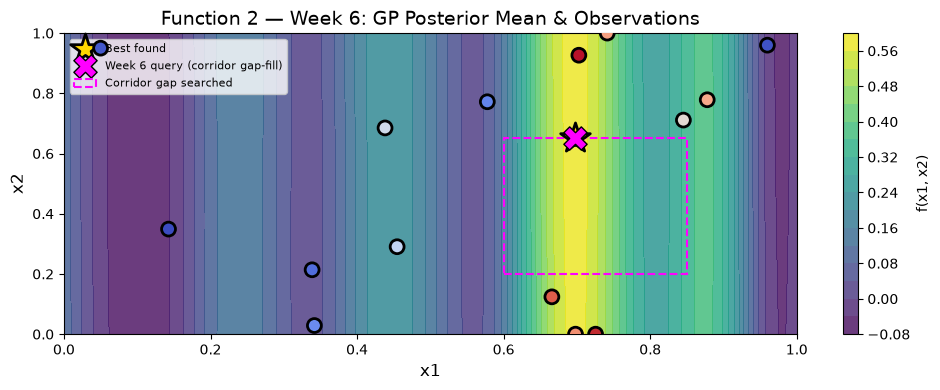

In [112]:
grid_res_w6 = 200
xs_w6 = np.linspace(0, 1, grid_res_w6)
ys_w6 = np.linspace(0, 1, grid_res_w6)
gx_w6, gy_w6 = np.meshgrid(xs_w6, ys_w6)
grid_w6 = np.column_stack([gx_w6.ravel(), gy_w6.ravel()])

mu_grid_w6, _ = result_week6['gp'].predict(grid_w6, return_std=True)
Z_mu_w6 = mu_grid_w6.reshape(gx_w6.shape)

fig, ax = plot_2d_bo_state(gx_w6, gy_w6, Z_mu_w6, X_updated, Y_updated,
                            title='Function 2 \u2014 Week 6: GP Posterior Mean & Observations')
ax.scatter(*next_point_week6, c='magenta', marker='X', s=280,
           edgecolor='black', label='Week 6 query (corridor gap-fill)', zorder=12)

import matplotlib.patches as patches
rect = patches.Rectangle((0.6, 0.2), 0.25, 0.45, linewidth=1.5, edgecolor='magenta',
                          facecolor='none', linestyle='--', label='Corridor gap searched')
ax.add_patch(rect)
ax.legend(loc='upper left', fontsize=8)
plt.show()

# Week 7: Refine the Corridor Definition

In [115]:
corridor_mask = (X_updated[:, 0] > 0.6) & (X_updated[:, 0] < 0.9)
corridor_pts  = X_updated[corridor_mask]
corridor_y    = Y_updated[corridor_mask]
order         = np.argsort(corridor_pts[:, 1])

print("Points with x1 in (0.6, 0.9), sorted by x2:\n")
for xi, yi in zip(corridor_pts[order], corridor_y[order]):
    print(f"  x = ({xi[0]:.4f}, {xi[1]:.4f})   y = {yi:.4f}")

Points with x1 in (0.6, 0.9), sorted by x2:

  x = (0.6981, 0.0000)   y = 0.4668
  x = (0.7255, 0.0000)   y = 0.5945
  x = (0.6658, 0.1240)   y = 0.5390
  x = (0.6977, 0.6500)   y = 0.6195
  x = (0.8453, 0.7111)   y = 0.2940
  x = (0.8778, 0.7786)   y = 0.4206
  x = (0.7026, 0.9266)   y = 0.6112
  x = (0.7413, 1.0000)   y = 0.4360


**Observation:** x1 = 0.845 (y = 0.294) scores far below the x1~0.70 points nearby (y = 0.44-0.62). The genuinely strong x1 range is narrower than previously assumed. It should be 0.65-0.75, not the full 0.6-0.85 used in Week 6.

# Week 7: Check Whether the Model Can Still Distinguish Signal from Noise Here

Before trusting the acquisition function's suggestion, check what the GP actually predicts across the untested gap (x2 between 0.65 and 0.93, at the narrowed x1≈0.70).

In [122]:
x2_probe = np.linspace(0.6, 1.0, 9)
probe_pts = np.column_stack([np.full_like(x2_probe, 0.70), x2_probe])

mu_probe, std_probe = gpr_wide.predict(probe_pts, return_std=True)
print("Predicted mean/std along x1=0.70, varying x2:\n")
for x2v, m, s in zip(x2_probe, mu_probe, std_probe):
    print(f"  x2={x2v:.3f}: mu={m:.4f}  std={s:.4f}")

print(f"\nFitted noise level: {gpr_wide.kernel_.k2.noise_level:.4f}")

Predicted mean/std along x1=0.70, varying x2:

  x2=0.600: mu=0.5773  std=0.0779
  x2=0.650: mu=0.5777  std=0.0781
  x2=0.700: mu=0.5780  std=0.0784
  x2=0.750: mu=0.5783  std=0.0787
  x2=0.800: mu=0.5785  std=0.0790
  x2=0.850: mu=0.5787  std=0.0794
  x2=0.900: mu=0.5789  std=0.0799
  x2=0.950: mu=0.5791  std=0.0803
  x2=1.000: mu=0.5792  std=0.0809

Fitted noise level: 0.0757


**Observation:** The predicted mean barely changes across this whole range (0.577 to 0.579). The noise level has grown large enough that the GP can no longer tell whether there is a real peak between the two known-good points, or just smooth noise. This means the acquisition function's suggestion here isn't very informative. It will likely just repeat a point close to one we already have.<br><br>
**Decision:** As the model's posterior is nearly flat across this gap, the standard acquisition step wouldn't add much new information here. Instead of trusting it blindly, this week's query is placed **manually** at the midpoint of the untested gap (x2 ≈ 0.79), within the narrowed x1 range. This is the point that would do the most to resolve whether a real peak exists between the two known-good results, which the model itself currently cannot judge.

In [127]:
beta_week7 = 0.7   # lowered from Week 6's 1.0 -- continued shift toward exploitation

# For reference: what the (largely uninformative, near-flat-posterior) acquisition
# function alone would suggest in this narrowed range
result_week7_auto = bayesian_optimization_step(X_updated, Y_updated,
                                                [(0.65, 0.75), (0.65, 0.93)],
                                                beta=beta_week7, kernel=kernel_week4)
print(f"Automatic suggestion: {result_week7_auto['next_point']}, "
      f"UCB={result_week7_auto['ucb']:.4f}")

# Manual override: the actual midpoint of the untested gap, chosen because the automatic
# suggestion above is not meaningfully different from points already sampled
next_point_week7 = np.array([0.70, 0.79])
mu_w7, std_w7 = result_week7_auto['gp'].predict(next_point_week7.reshape(1, -1), return_std=True)

print(f"\nManually selected Week 7 Query Point: {next_point_week7}")
print(f"Predicted Mean(\u03bc): {mu_w7[0]:.6e}")
print(f"Predicted Std (\u03c3): {std_w7[0]:.6e}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Automatic suggestion: [0.69660711 0.93      ], UCB=0.6358

Manually selected Week 7 Query Point: [0.7  0.79]
Predicted Mean(μ): 5.784674e-01
Predicted Std (σ): 7.896157e-02


# Portal Submission 

In [129]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point_week7[0]:.6f}-{next_point_week7[1]:.6f}"
print("Points to be submitted (Week 1):", '0.725451-0.000000')
print("Points to be submitted (Week 2):", '0.959920-0.959920')
print("Points to be submitted (Week 3):", '0.698058-0.000000')
print("Points to be submitted (Week 4):", '0.741335-1.000000')
print("Points to be submitted (Week 5):", "0.050000-0.950000")
print("Points to be submitted (Week 6):", "0.697679-0.650000")
print("Points to be submitted (Week 7):", submission_str)
print()

Points to be submitted (Week 1): 0.725451-0.000000
Points to be submitted (Week 2): 0.959920-0.959920
Points to be submitted (Week 3): 0.698058-0.000000
Points to be submitted (Week 4): 0.741335-1.000000
Points to be submitted (Week 5): 0.050000-0.950000
Points to be submitted (Week 6): 0.697679-0.650000
Points to be submitted (Week 7): 0.700000-0.790000



# Plot the Progress of the optimisation process

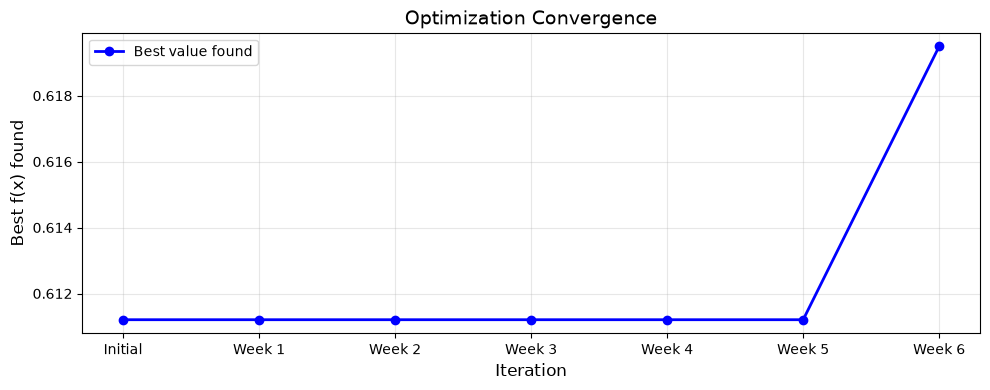

Best value found so far: 0.6194965226381177


In [133]:
# Track best-value-found progress across weeks
best_so_far = [
    0.6112052157614438,                              # best after initial 10 points
    max(0.6112052157614438, 0.594525526714632),      # best after Week 1
    max(0.6112052157614438, -0.053254980810696906),  # best after Week 2
    max(0.6112052157614438, 0.46684490847445986),    # best after Week 3
    max(0.6112052157614438, 0.4360156328364332),     # best after Week 4
    max(0.6112052157614438, -0.044684125031317246),  # best after Week 5   
    max(0.6112052157614438, 0.6194965226381177),     # best after Week 6
]

fig, ax     = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(['Initial', 'Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6'])
plt.show()

print("Best value found so far:", max(best_so_far))